In [1]:
import sys
sys.path.append('../..')
from utils.data import RK4DataGenerator, stack_real_values, mono_beta, sin_beta
import utils.plotting as plotting
import numpy as np
import pandas as pd

2026-07-14 22:23:04.421502: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-07-14 22:23:04.509230: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-14 22:23:05.445920: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-07-14 22:23:07.614003: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

In [2]:
t_0, t_f, N = 0, 50, 100
nop_data = 50
S0, I0, R0 = 99, 1, 0
noise_std = N * 0.00
data_t = np.linspace(t_0, t_f, nop_data)

In [3]:
sin_rkdata = RK4DataGenerator(sin_beta, 
    t_0=t_0, 
    t_f=t_f, 
    N=N, 
    S0=S0, I0=I0, R0=R0
)

In [4]:
sin_sir_data = sin_rkdata.generate(data_t)

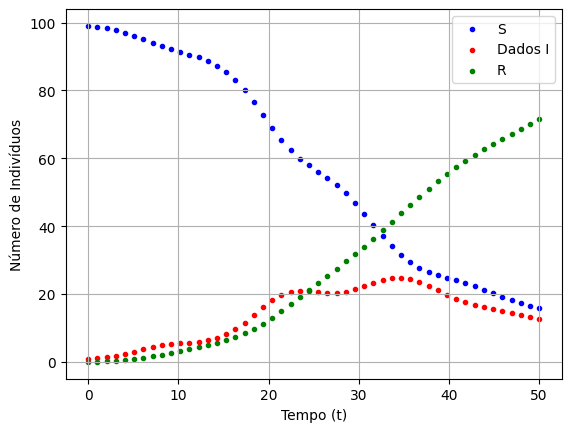

In [5]:
plotting.plot_rk_data(data_t, sin_sir_data, figname="rk-data-sin-beta")

In [6]:
mono_rkdata = RK4DataGenerator(mono_beta, 
    t_0=t_0, 
    t_f=t_f, 
    N=N, 
    S0=S0, I0=I0, R0=R0
)

In [7]:
mono_sir_data = mono_rkdata.generate(data_t)

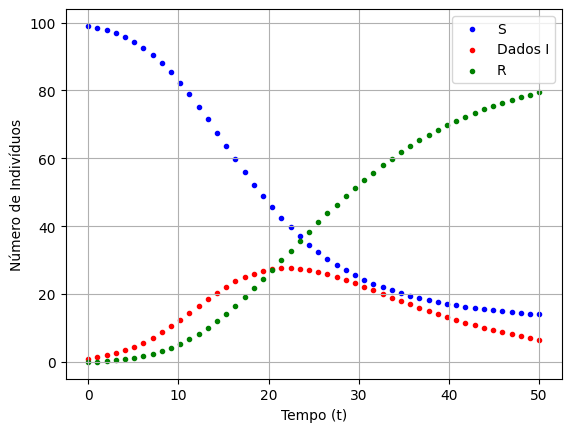

In [8]:
plotting.plot_rk_data(data_t, mono_sir_data, figname="rk-data-mono-beta")

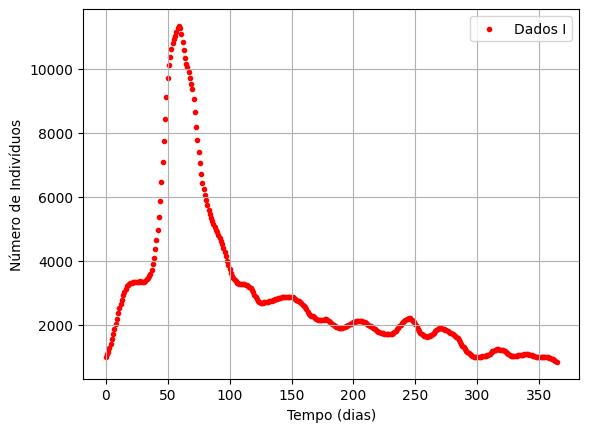

In [9]:
df = pd.read_csv("../../data/sir-am-14d.csv")
I_data = df["I"].to_numpy()
t_0, t_f = 0, len(I_data) - 1
data_t = np.linspace(t_0, t_f, len(I_data))
plotting.plot_prevalence_data(data_t, I_data, 
    xlabel="Tempo (dias)",
    figname="smoothed-data-sus-AM-2023")

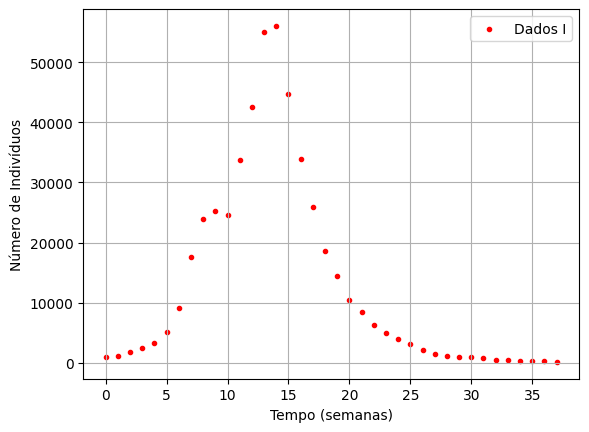

In [10]:
df = pd.read_csv("../../data/FlunetData_United States of America_All Sites_for_28 October 2024 to 20 October 2025.csv")
df = df.sort_values("Week start date (ISO 8601 calendar)")
df = df[df["Surveillance site type"] == "Non-sentinel"]

I_data = df["Influenza positive"].to_numpy()

t_0, t_f = 0, len(I_data) - 1
data_t = np.linspace(t_0, t_f, len(I_data))
N = 341784857 # population size
gamma = 1

plotting.plot_prevalence_data(data_t, I_data, 
    xlabel="Tempo (semanas)", 
    figname="data-eua-2025")

In [11]:
from utils.data import apply_savgol_filter

humidity = pd.read_csv("../../data/daily_mean_humidity.csv")
humidity_values = humidity.to_numpy()[:,1].astype("float64")
humidity_t = np.linspace(0, len(humidity_values) - 1, len(humidity_values))
smoothed_humidity_values = apply_savgol_filter(humidity_t, humidity_values, window=50)

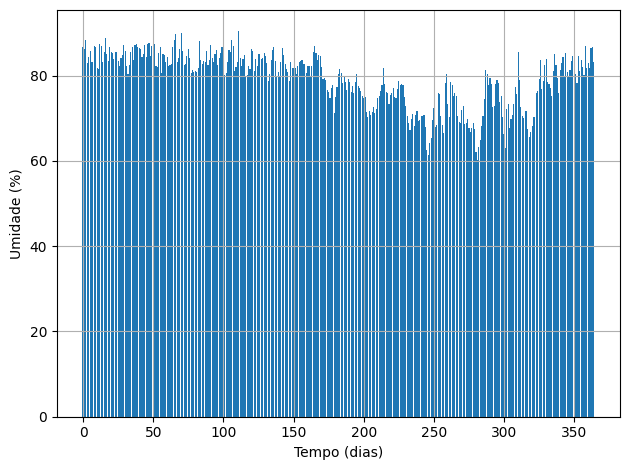

In [12]:
plotting.plot_climate_variable(humidity_values, "Umidade (%)",
    xlabel="Tempo (dias)",
    figname="daily-humidity-AM-2023")

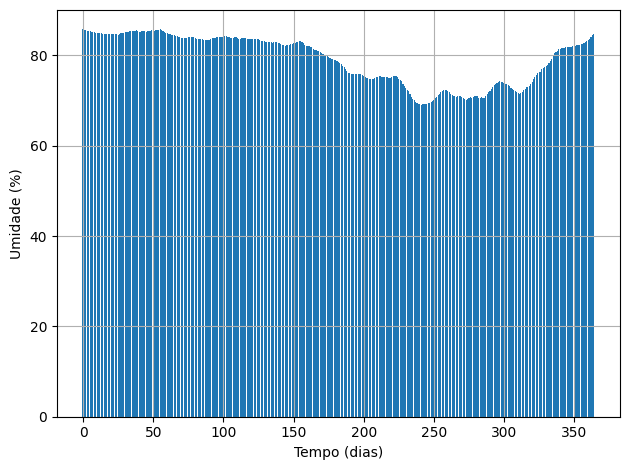

In [13]:
plotting.plot_climate_variable(smoothed_humidity_values, "Umidade (%)",
    xlabel="Tempo (dias)",
    figname="smoothed-daily-humidity-AM-2023")

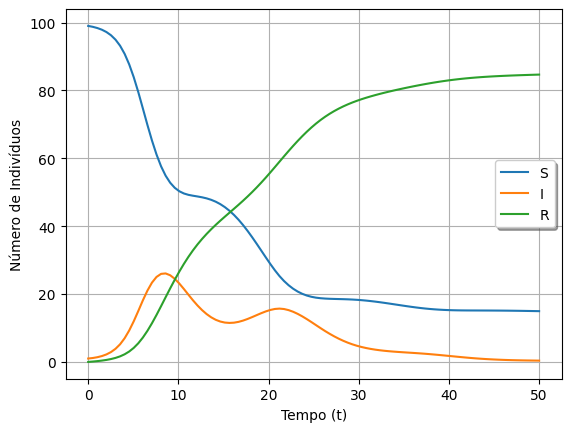

In [14]:
data_t = np.linspace(0, 50, 100)

sin_rkdata = RK4DataGenerator(lambda t: 0.4 * np.sin(0.4 * t) + 0.45, 
    gamma=0.2,
    t_0=0, 
    t_f=50, 
    N=100, 
    S0=S0, I0=I0, R0=R0
)


sin_sir_data = sin_rkdata.generate(data_t)
plotting.plot_rk_curves(data_t, sin_sir_data, figname="sin-beta-data-example")

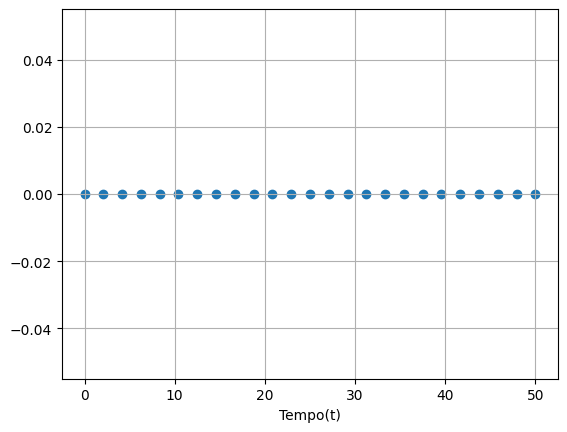

In [15]:
from matplotlib import pyplot as plt
data_t = np.linspace(0, 50, 25)
plt.scatter(data_t, np.zeros(len(data_t)))
plt.xlabel("Tempo(t)")
plt.grid()
plt.savefig(f"../../images/exemplo-pontos-colocacao.png")

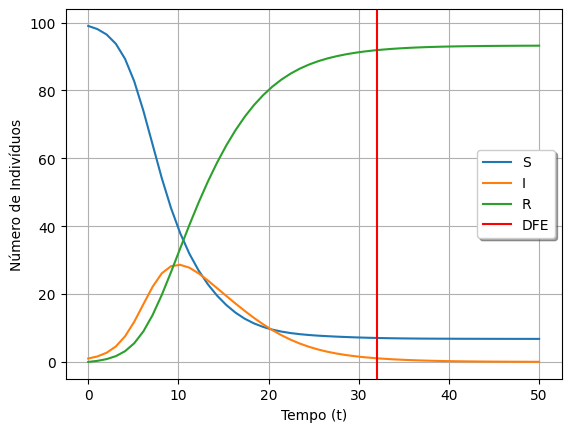

In [16]:
from utils.data import RK4DataGenerator, stack_real_values, sin_beta, mono_beta, sin_beta_dfe, first_below_threshold

gamma = 0.24
t_0, t_f, N = 0, 50, 100
nop_data = 50
S0, I0, R0 = 99, 1, 0

test_t = np.linspace(t_0, t_f, nop_data)
rkdata = RK4DataGenerator(sin_beta_dfe,
    gamma=gamma,
    t_0=t_0, 
    t_f=t_f, 
    N=N, 
    S0=S0, I0=I0, R0=R0
)
sir_real = rkdata.generate(test_t)
sir_data = rkdata.generate(test_t, noise_std)

dfe_value, dfe_point = first_below_threshold(sir_data[:,1], threshold=1)

plotting.plot_rk_curves(test_t, sir_real, vlines=[(dfe_point, "DFE", "red")], figname="exemplo-com-dfe")

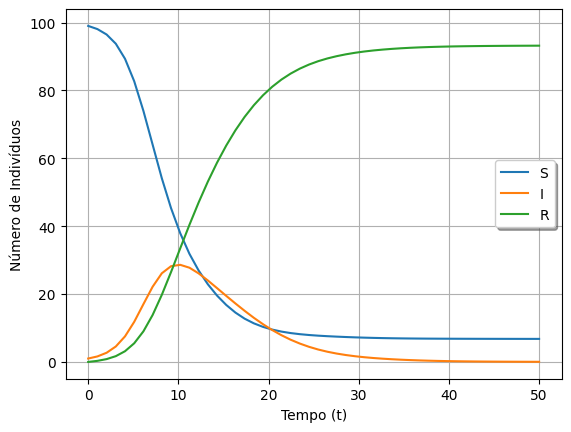

In [17]:
plotting.plot_rk_curves(test_t, sir_real, figname="exemplo-com-dfe-2")

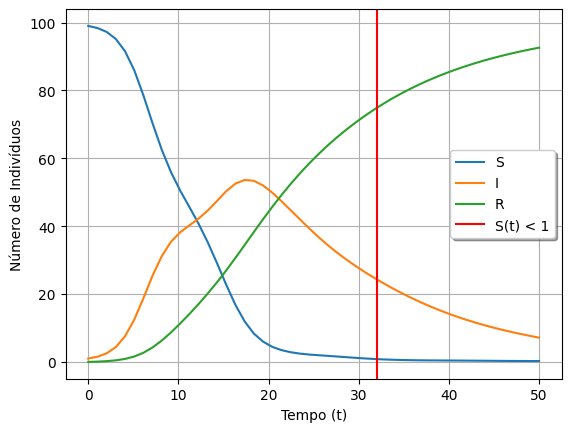

In [18]:
from utils.data import sin_beta_szero
t_0, t_f, N = 0, 50, 100
nop_data = 50
S0, I0, R0 = 99, 1, 0
noise_std = N * 0.00
gamma = 0.07
test_t = np.linspace(t_0, t_f, nop_data)
rkdata = RK4DataGenerator(sin_beta_szero,
    gamma=gamma,
    t_0=t_0, 
    t_f=t_f, 
    N=N, 
    S0=S0, I0=I0, R0=R0
)
sir_real = rkdata.generate(test_t)
sir_data = rkdata.generate(test_t, noise_std)

szero_value, szero_point = first_below_threshold(sir_data[:,0] * sir_data[:,1], threshold=20) 

plotting.plot_rk_curves(test_t, sir_real, vlines=[(szero_point, "S(t) < 1", "red")], figname="exemplo-com-szero")

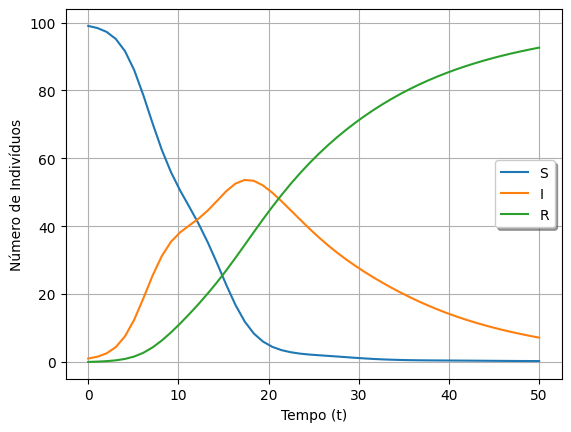

In [19]:
plotting.plot_rk_curves(test_t, sir_real, figname="exemplo-sem-dfe")

In [20]:
def random_points_3d(n_points, x_range=(0,1), y_range=(0,1), z_range=(0,1)):
    """
    Generate random uniformly distributed points in 3D.
    
    Parameters:
    - n_points: number of points to generate
    - ranges: (min, max) for each dimension
    
    Returns:
    - points: (N, 3) array of collocation points
    """
    x = np.random.uniform(x_range[0], x_range[1], n_points)
    y = np.random.uniform(y_range[0], y_range[1], n_points)
    z = np.random.uniform(z_range[0], z_range[1], n_points)
    
    return np.column_stack((x, y, z))

def lhs_3d(n_points, x_range=(0,1), y_range=(0,1), z_range=(0,1)):
    """
    Generate Latin Hypercube samples in 3D.
    Better space-filling than pure random.
    """
    # Generate LHS samples in [0,1]^3
    samples = np.zeros((n_points, 3))
    
    for i in range(3):
        # Divide [0,1] into n_points intervals
        cut = np.linspace(0, 1, n_points + 1)
        # Random point in each interval
        samples[:, i] = np.random.uniform(cut[:-1], cut[1:])
        # Shuffle
        np.random.shuffle(samples[:, i])
    
    # Scale to ranges
    samples[:, 0] = x_range[0] + samples[:, 0] * (x_range[1] - x_range[0])
    samples[:, 1] = y_range[0] + samples[:, 1] * (y_range[1] - y_range[0])
    samples[:, 2] = z_range[0] + samples[:, 2] * (z_range[1] - z_range[0])
    
    return samples

def uniform_grid_3d(nx, ny, nz, x_range=(0,1), y_range=(0,1), z_range=(0,1)):
    """
    Generate uniform grid points in 3D.
    
    Parameters:
    - nx, ny, nz: number of points along each axis
    - x_range, y_range, z_range: (min, max) for each dimension
    
    Returns:
    - points: (N, 3) array of collocation points
    """
    x = np.linspace(x_range[0], x_range[1], nx)
    y = np.linspace(y_range[0], y_range[1], ny)
    z = np.linspace(z_range[0], z_range[1], nz)
    
    X, Y, Z = np.meshgrid(x, y, z, indexing='ij')
    points = np.column_stack((X.ravel(), Y.ravel(), Z.ravel()))
    
    return points

def visualize_3d_points(points, title="3D Collocation Points"):
    """
    Visualize 3D points with matplotlib.
    """
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    ax.scatter(points[:, 0], points[:, 1], points[:, 2], 
               c='blue', alpha=0.6, s=20)
    
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title(title)
    
    # Equal aspect ratio
    max_range = np.array([points[:,0].max()-points[:,0].min(),
                          points[:,1].max()-points[:,1].min(),
                          points[:,2].max()-points[:,2].min()]).max() / 2.0
    
    mid_x = (points[:,0].max()+points[:,0].min()) * 0.5
    mid_y = (points[:,1].max()+points[:,1].min()) * 0.5
    mid_z = (points[:,2].max()+points[:,2].min()) * 0.5
    ax.set_xlim(mid_x - max_range, mid_x + max_range)
    ax.set_ylim(mid_y - max_range, mid_y + max_range)
    ax.set_zlim(mid_z - max_range, mid_z + max_range)
    
    plt.show()
    

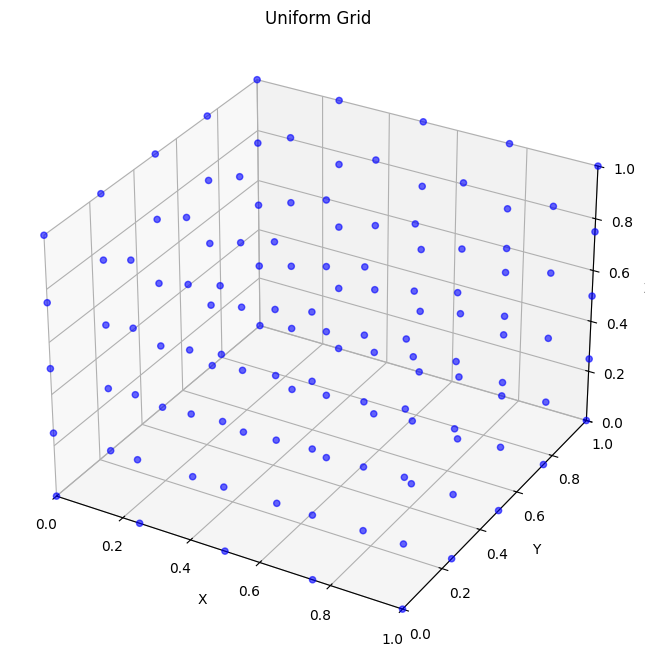

In [21]:
points = uniform_grid_3d(5, 5, 5)
visualize_3d_points(points, "Uniform Grid")

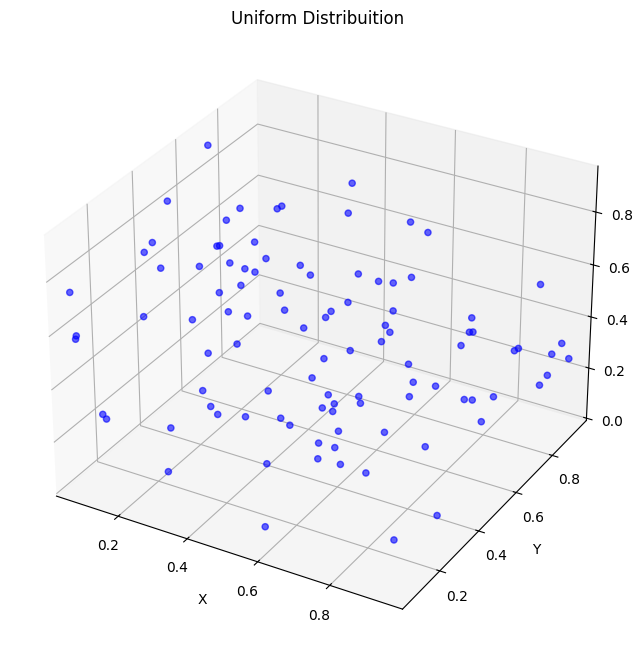

In [22]:
points = random_points_3d(100)
visualize_3d_points(points, "Uniform Distribuition")

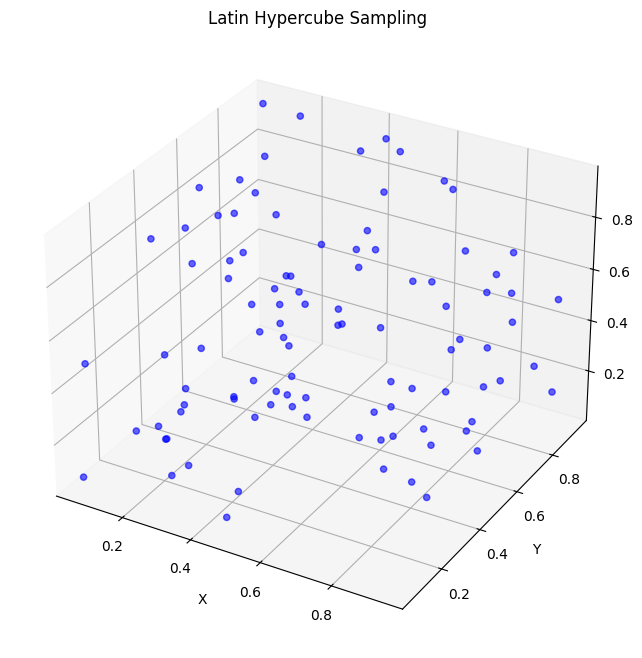

In [23]:
lhs_points = lhs_3d(100)
visualize_3d_points(lhs_points, "Latin Hypercube Sampling")